# Data Quality Checks

Inspection notebook for the processed collapse dataset. This notebook reads the data, summarizes completeness and case coverage, checks duplicate identifiers, and flags invalid factor values without modifying the dataset.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("default")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)


In [2]:
project_root = Path.cwd()
data_path = project_root / "data" / "processed" / "collapse_dataset_expanded.csv"

if not data_path.exists():
    project_root = Path.cwd().parent
    data_path = project_root / "data" / "processed" / "collapse_dataset_expanded.csv"

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at {data_path}")

data_path

WindowsPath('d:/ADRIAN/projects/Collapse_Pathways/data/processed/collapse_dataset_expanded.csv')

In [3]:
df = pd.read_csv(data_path)
df.head()

,case_id,case_name,case_type,region,period_start,period_end,time_window_years,phase_label,collapse_outcome,collapse_within_next_window,political_fragmentation,elite_conflict,succession_crisis,legitimacy_crisis,administrative_overload,corruption_governance_failure,social_inequality,social_unrest_rebellion,demographic_pressure,migration_pressure,ethnic_sectarian_fragmentation,urban_decline,fiscal_crisis,taxation_extraction_pressure,trade_disruption,inflation_currency_instability,resource_dependency,agricultural_decline,drought_climate_stress,flood_environmental_shock,temperature_anomaly,ecological_degradation,food_insecurity,external_invasion_pressure,civil_war_internal_conflict,military_overstretch,territorial_loss,institutional_rigidity,adaptive_capacity,logistics_food_storage_resilience,alliance_network_strength,recovery_capacity,data_confidence,source_count,notes
0,akkadian_-2350_-2325,Akkadian Empire,ancient,Mesopotamia,-2350,-2325,25,stable,0,0,0,1,1,0,1,9,9,0,9,9,9,0,0,1,0,9,2,9,9,9,9,9,0,1,0,2,0,1,3,3,2,3,low,2,"The empire is expanding and still resilient, t..."
1,akkadian_-2325_-2300,Akkadian Empire,ancient,Mesopotamia,-2325,-2300,25,stable,0,0,0,1,1,0,1,9,9,0,9,9,9,0,0,1,0,9,2,9,9,9,9,9,0,1,0,2,0,1,3,3,2,3,low,2,"The empire is expanding and still resilient, t..."
2,akkadian_-2300_-2275,Akkadian Empire,ancient,Mesopotamia,-2300,-2275,25,stressed,1,0,1,2,1,1,2,9,9,1,9,9,9,1,1,2,1,9,3,1,9,9,9,9,1,2,2,3,1,2,2,2,2,2,low,3,"Imperial overextension, elite conflict, and de..."
3,akkadian_-2275_-2250,Akkadian Empire,ancient,Mesopotamia,-2275,-2250,25,stressed,1,0,1,2,1,1,2,9,9,1,9,9,9,1,1,2,1,9,3,1,9,9,9,9,1,2,2,3,1,2,2,2,2,2,low,3,"Imperial overextension, elite conflict, and de..."
4,akkadian_-2250_-2225,Akkadian Empire,ancient,Mesopotamia,-2250,-2225,25,decline,2,0,2,2,1,2,2,2,2,2,9,1,9,2,2,2,2,9,3,1,1,9,9,9,2,1,2,3,2,2,1,1,1,2,low,4,"Late-apogee strain raises conflict, overextens..."


## Dataset shape

In [4]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 174
Columns: 45


## All columns

In [5]:
pd.Index(df.columns, name="column_name").to_series().reset_index(drop=True)

0                               case_id
1                             case_name
2                             case_type
3                                region
4                          period_start
5                            period_end
6                     time_window_years
7                           phase_label
8                      collapse_outcome
9           collapse_within_next_window
10              political_fragmentation
11                       elite_conflict
12                    succession_crisis
13                    legitimacy_crisis
14              administrative_overload
15        corruption_governance_failure
16                    social_inequality
17              social_unrest_rebellion
18                 demographic_pressure
19                   migration_pressure
20       ethnic_sectarian_fragmentation
21                        urban_decline
22                        fiscal_crisis
23         taxation_extraction_pressure
24                     trade_disruption


## Missing values by column

In [6]:
missing_by_column = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean().mul(100),
    })
    .sort_values(["missing_count", "missing_pct"], ascending=False)
)

missing_by_column

,missing_count,missing_pct
case_id,0,0.0
case_name,0,0.0
case_type,0,0.0
region,0,0.0
period_start,0,0.0
period_end,0,0.0
time_window_years,0,0.0
phase_label,0,0.0
collapse_outcome,0,0.0
collapse_within_next_window,0,0.0


## Case counts by case_name

In [7]:
case_counts = (
    df["case_name"]
    .value_counts(dropna=False)
    .rename_axis("case_name")
    .reset_index(name="row_count")
)

case_counts

,case_name,row_count
0,Western Roman Empire,24
1,Classic Mesopotamian States,20
2,Easter Island,20
3,Byzantine Decline,19
4,Khmer Empire,18
5,Maya,14
6,Akkadian Empire,8
7,Bronze Age Collapse States,8
8,Han Dynasty Crisis,7
9,Inca Empire,7


## Time-window counts by case_name

In [8]:
time_window_counts = (
    df.groupby("case_name", dropna=False)
    .agg(
        time_window_count=("case_id", "size"),
        min_period_start=("period_start", "min"),
        max_period_end=("period_end", "max"),
        window_sizes=("time_window_years", lambda s: sorted(pd.Series(s).dropna().unique().tolist())),
    )
    .sort_values("time_window_count", ascending=False)
)

time_window_counts

,time_window_count,min_period_start,max_period_end,window_sizes
case_name,,,,
Western Roman Empire,24,-100,500,[25]
Easter Island,20,1200,1700,[25]
Classic Mesopotamian States,20,-2100,-1600,[25]
Byzantine Decline,19,1000,1453,"[3, 25]"
Khmer Empire,18,1000,1450,[25]
Maya,14,600,950,[25]
Akkadian Empire,8,-2350,-2150,[25]
Bronze Age Collapse States,8,-1300,-1100,[25]
Han Dynasty Crisis,7,150,220,[10]


## Duplicate case_id rows

In [9]:
duplicate_case_id_rows = df[df.duplicated(subset="case_id", keep=False)].sort_values("case_id")
print(f"Duplicate rows found: {len(duplicate_case_id_rows)}")
duplicate_case_id_rows

Duplicate rows found: 0


,case_id,case_name,case_type,region,period_start,period_end,time_window_years,phase_label,collapse_outcome,collapse_within_next_window,political_fragmentation,elite_conflict,succession_crisis,legitimacy_crisis,administrative_overload,corruption_governance_failure,social_inequality,social_unrest_rebellion,demographic_pressure,migration_pressure,ethnic_sectarian_fragmentation,urban_decline,fiscal_crisis,taxation_extraction_pressure,trade_disruption,inflation_currency_instability,resource_dependency,agricultural_decline,drought_climate_stress,flood_environmental_shock,temperature_anomaly,ecological_degradation,food_insecurity,external_invasion_pressure,civil_war_internal_conflict,military_overstretch,territorial_loss,institutional_rigidity,adaptive_capacity,logistics_food_storage_resilience,alliance_network_strength,recovery_capacity,data_confidence,source_count,notes


## Factor columns with invalid values

In [10]:
factor_columns = [
    "political_fragmentation",
    "elite_conflict",
    "succession_crisis",
    "legitimacy_crisis",
    "administrative_overload",
    "corruption_governance_failure",
    "social_inequality",
    "social_unrest_rebellion",
    "demographic_pressure",
    "migration_pressure",
    "ethnic_sectarian_fragmentation",
    "urban_decline",
    "fiscal_crisis",
    "taxation_extraction_pressure",
    "trade_disruption",
    "inflation_currency_instability",
    "resource_dependency",
    "agricultural_decline",
    "drought_climate_stress",
    "flood_environmental_shock",
    "temperature_anomaly",
    "ecological_degradation",
    "food_insecurity",
    "external_invasion_pressure",
    "civil_war_internal_conflict",
    "military_overstretch",
    "territorial_loss",
    "institutional_rigidity",
    "adaptive_capacity",
    "logistics_food_storage_resilience",
    "alliance_network_strength",
    "recovery_capacity",
]

valid_factor_values = {"0", "1", "2", "3", "9", ""}

invalid_factor_values = []
for column in factor_columns:
    normalized = df[column].fillna("").astype(str).str.strip()
    invalid_mask = ~normalized.isin(valid_factor_values)
    if invalid_mask.any():
        invalid_factor_values.append({
            "column": column,
            "invalid_row_count": int(invalid_mask.sum()),
            "invalid_values": sorted(normalized[invalid_mask].unique().tolist()),
        })

invalid_factor_summary = pd.DataFrame(invalid_factor_values)

if invalid_factor_summary.empty:
    print("No invalid factor values found.")

invalid_factor_summary

No invalid factor values found.


""


## Plot: number of rows per case

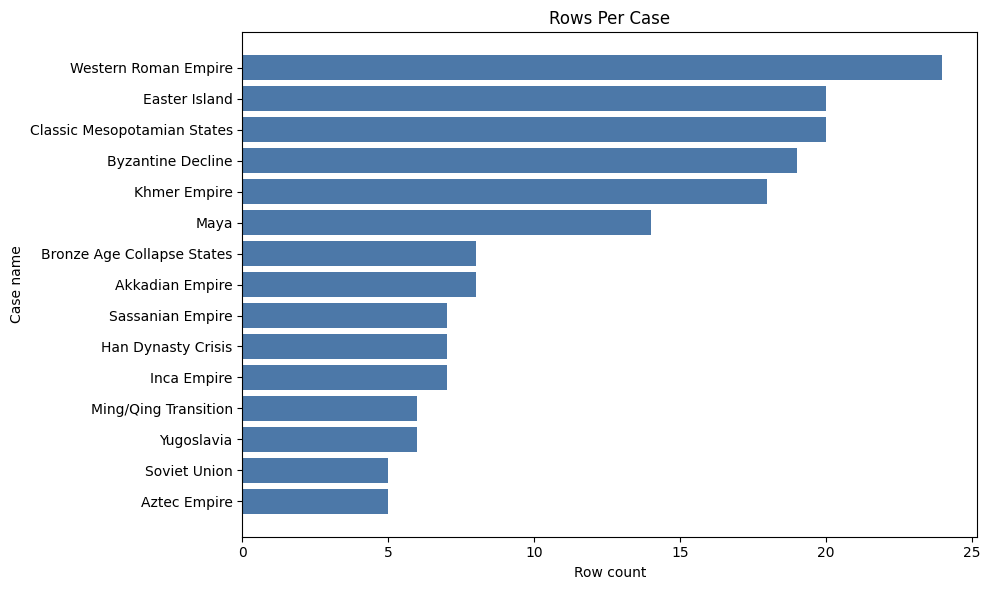

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_case_counts = case_counts.sort_values("row_count", ascending=True)
ax.barh(plot_case_counts["case_name"], plot_case_counts["row_count"], color="#4C78A8")
ax.set_title("Rows Per Case")
ax.set_xlabel("Row count")
ax.set_ylabel("Case name")
plt.tight_layout()
plt.show()

## Plot: missing values by column

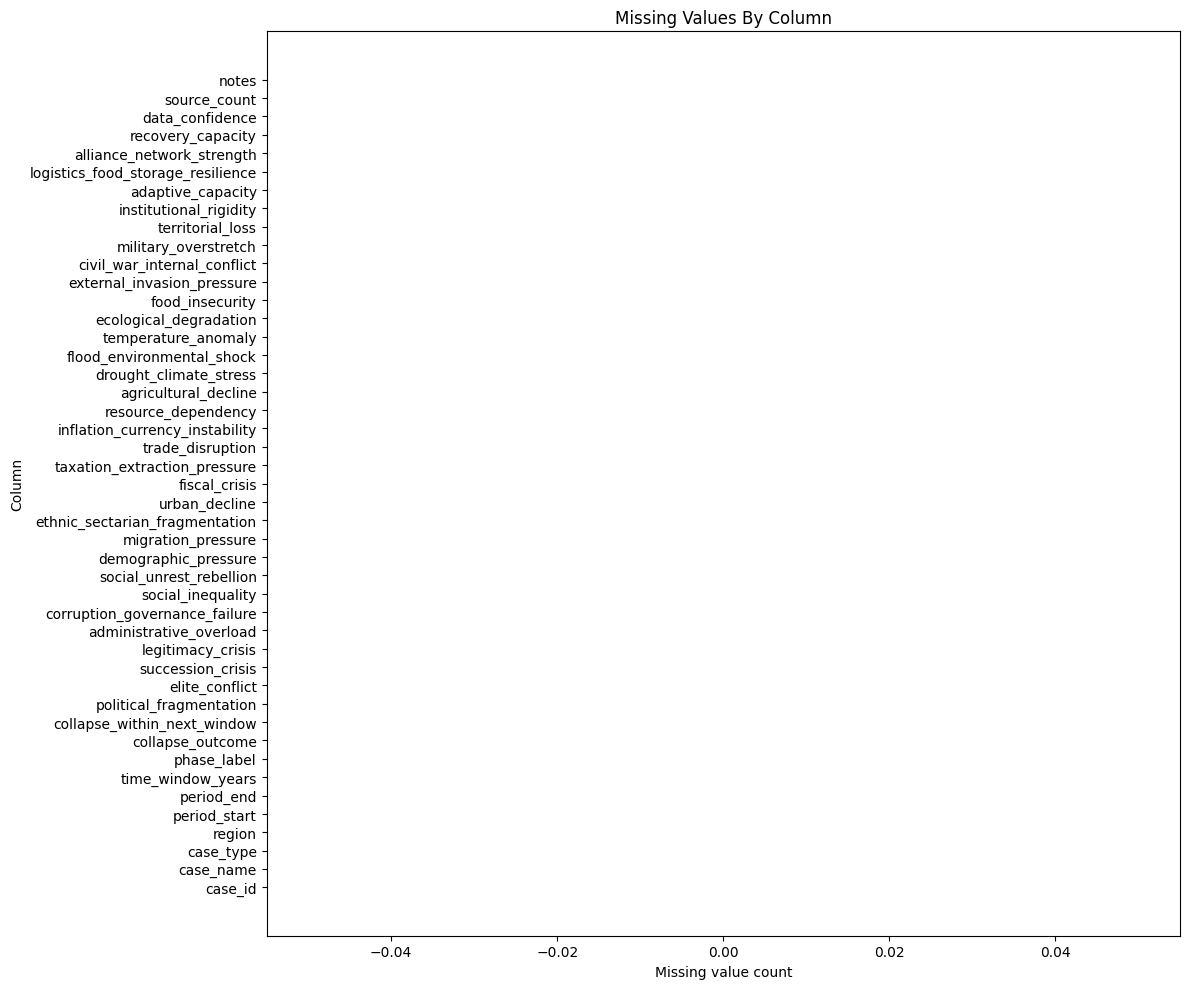

In [12]:
fig, ax = plt.subplots(figsize=(12, 10))
plot_missing = missing_by_column.sort_values("missing_count", ascending=True)
ax.barh(plot_missing.index, plot_missing["missing_count"], color="#F58518")
ax.set_title("Missing Values By Column")
ax.set_xlabel("Missing value count")
ax.set_ylabel("Column")
plt.tight_layout()
plt.show()